# Section 14 — Exploratory analysis and the first threshold estimate (steps 72–79)

**The final section of the Phoenix pilot — and the first scientific result.** It looks at the
central relationship of the whole project, the tree **cooling advantage** against **compound
stress** (the CSI), and produces a **first threshold estimate** for Phoenix. A threshold, if
present, appears as a clear **bend**: cooling advantage roughly flat / slowly declining at low
stress, then dropping more steeply beyond some point — and, mechanistically, **ET should fall
beyond the same stress level**.

> **Blocker-remediation run.** The scalar CSI is now secondary and uses VPD demand plus
> **root-zone soil-moisture supply (`sm_z`)**. NDMI is retained only as a vegetation-side
> check. The primary RQ1 detector is the separate two-dimensional VPD_z × SM_z response
> surface (Section 15); this notebook keeps the one-dimensional CSI threshold as a secondary
> diagnostic. The headline sample is day-only with `n_tree_valid ≥ 3`; lower-count, night,
> and pooled rows are explicitly labelled sensitivity analyses.

This notebook reads **only** `data/processed/master_table.parquet` (the Section 13 deliverable)
and imports the reusable analysis logic from `src/section14_threshold.py` (unit-tested in
`src/test_section14_threshold.py`), so every number and figure here is reproducible from saved
code.

## The honesty gate (the protocol's *common pitfall*, non-negotiable)
> A segmented (piecewise) regression **always** returns a breakpoint — even for a straight
> line or pure noise. Do **not** report a threshold on the strength of one fit.

We therefore report a Phoenix threshold as **credible only if ALL THREE hold**:
1. the **two methods agree** within their uncertainty — the segmented-regression breakpoint
   (with a bootstrap CI) and the **independent** `ruptures` change-point;
2. a **bend is visible** in the binned plot (post-breakpoint slope clearly steeper);
3. **ET declines** beyond the same CSI level (the mechanistic signature).

Otherwise the honest result is **“no robust threshold detected”** — a valid finding, not a
failure. We also compare the segmented fit against a plain **linear** fit (ΔR² / ΔAIC): if the
kink buys little over a straight line, that is itself evidence against a threshold.

## Data-adequacy caveats we carry throughout (from Sections 10–13)
- **Thin paired sample.** Only **9 paired block groups**, and
  **one** (`040139412001`, ~171 tree px) dominates; the other 8 rest on **1–6 tree px** (median
  `n_good_obs` = 2). Rows with `n_tree_valid < 3` remain visible but are sensitivity-only; the
  primary sample uses the persisted `sample_label == 'primary'` rule. A strict ≥10 check still
  collapses toward the dominant BG and is reported only as a stress test.
- **What drives the CSI axis.** CSI uses VPD_z demand plus robust-rescaled root-zone `sm_z`
  supply. `ndmi_z` is not called water supply and does not enter the primary CSI; it is carried
  only as an independent vegetation-condition check.
- **ET coverage.** `mean_et_tree` / `mean_esi_tree` are NaN on ~22.7 % of rows (the non-ET
  overpasses) — dropped pairwise in the ET overlay, never imputed.

## 0. Setup — imports, config, and the analysis module

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Repo root on sys.path so `config` and the Section 14 module import.
_REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (_REPO, _REPO / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import config
import section14_threshold as s14

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})
FIGS = config.FIGURES_DIR
FIGS.mkdir(parents=True, exist_ok=True)
print("repo:", _REPO)
print("master table:", (config.PROCESSED_DIR / "master_table.parquet"))
print("section14 module:", s14.__file__)

repo: /Users/jmlee/Documents/TreeProject/project
master table: /Users/jmlee/Documents/TreeProject/project/data/processed/master_table.parquet
section14 module: /Users/jmlee/Documents/TreeProject/project/src/section14_threshold.py


## 1. Load the master table (the ONLY input)

One row per (paired neighborhood, overpass). Section 13 must persist `local_hour`, `is_day`,
and `sample_label`; this notebook fails on a stale table instead of silently re-deriving the
B4 classification. Only `month` is derived here for QC.

In [2]:
mt = pd.read_parquet(config.PROCESSED_DIR / "master_table.parquet")

ts = pd.to_datetime(mt["overpass_timestamp"])
mt["month"] = ts.dt.month
# B4 single source of truth: never reconstruct persisted time/sample classifications here.
required_persisted = {"local_hour", "is_day", "sample_label"}
missing_persisted = sorted(required_persisted - set(mt.columns))
if missing_persisted:
    raise RuntimeError(f"stale Section-13 master table; missing persisted columns: {missing_persisted}")
expected_primary = mt[s14.COUNT_COL].ge(s14.DEFAULT_MIN_COUNT)
if not mt["sample_label"].eq("primary").equals(expected_primary):
    raise RuntimeError("sample_label does not match the predeclared n_tree_valid floor")

print(f"rows={len(mt)}  neighborhoods={mt['neighborhood_id'].nunique()}  "
      f"overpasses={mt['overpass_key'].nunique()}")
print("columns:", list(mt.columns)[:26])
mt[[s14.OUTCOME_COL, s14.CSI_COL, s14.ET_COL, s14.ESI_COL, s14.COUNT_COL]].describe().round(3)


rows=266  neighborhoods=9  overpasses=54
columns: ['neighborhood_id', 'overpass_timestamp', 'overpass_key', 'city', 'local_hour', 'is_day', 'sample_label', 'cooling_advantage', 'mean_lst_tree', 'mean_lst_reference', 'mean_et_tree', 'mean_esi_tree', 'mean_csi_tree', 'mean_demand_stress_tree', 'mean_supply_stress_tree', 'mean_vpd_z_tree', 'mean_sm_z_tree', 'mean_ndmi_z_tree', 'mean_impervious', 'mean_canopy', 'aridity', 'irrigation_proxy', 'functional_type', 'functional_leaf_habit', 'median_income', 'pct_poc']


,cooling_advantage,mean_csi_tree,mean_et_tree,mean_esi_tree,n_tree_valid
count,266.000,237.000,205.000,205.000,266.000
mean,3.755,0.505,195.250,0.580,17.835
std,3.928,0.401,109.935,0.126,45.987
min,-7.441,0.000,0.000,0.000,1.000
25%,0.715,0.000,104.367,0.561,1.000
50%,2.881,0.491,209.715,0.605,2.000
75%,6.031,0.834,277.862,0.640,7.000
max,19.363,1.368,438.957,0.727,179.000


## Step 72 — Scatter: cooling advantage vs CSI, one point per neighborhood per overpass

We colour by neighborhood and size by `n_tree_valid` (so the single well-sampled BG and the
many single-pixel rows are visually distinct). We also print the headline shape descriptors
(Pearson / Spearman correlation, OLS slope) — **before** fitting any threshold.

SHAPE of the cooling-advantage vs CSI cloud (full sample, n=237):
  Pearson  r = -0.100  (p = 0.124)
  Spearman r = -0.106  (p = 0.104)
  OLS slope  = -1.011 K per CSI unit


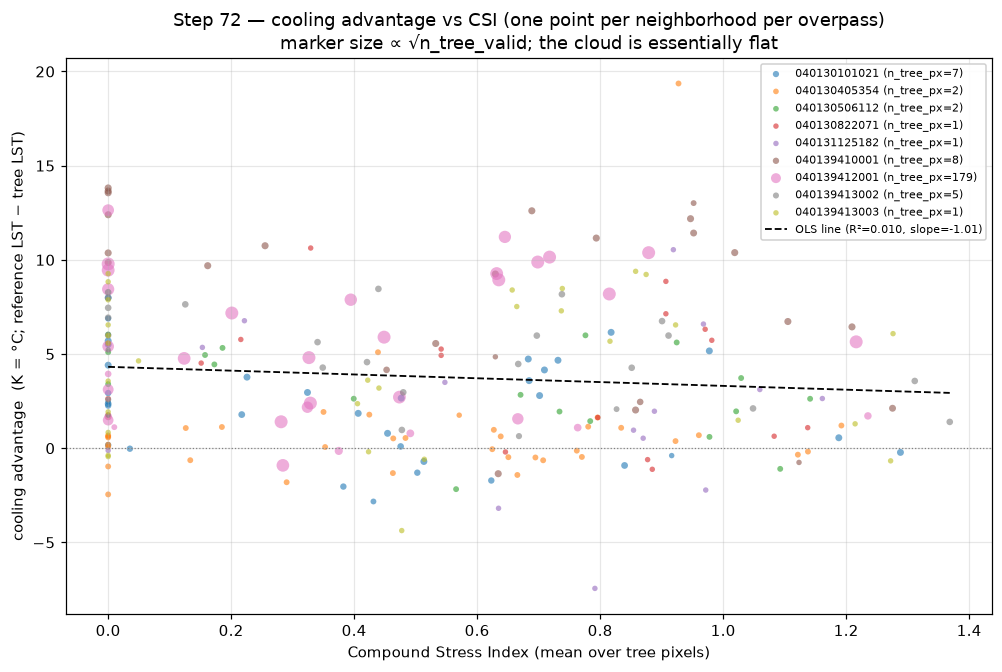

In [3]:
x_all = mt[s14.CSI_COL].to_numpy()
y_all = mt[s14.OUTCOME_COL].to_numpy()

shape = s14.describe_shape(x_all, y_all)
print("SHAPE of the cooling-advantage vs CSI cloud (full sample, n=%d):" % shape["n"])
print(f"  Pearson  r = {shape['pearson_r']:+.3f}  (p = {shape['pearson_p']:.3f})")
print(f"  Spearman r = {shape['spearman_r']:+.3f}  (p = {shape['spearman_p']:.3f})")
print(f"  OLS slope  = {shape['ols_slope']:+.3f} K per CSI unit")

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
neighs = sorted(mt["neighborhood_id"].unique())
cmap = plt.get_cmap("tab10")
for i, g in enumerate(neighs):
    sub = mt[mt["neighborhood_id"] == g]
    ax.scatter(sub[s14.CSI_COL], sub[s14.OUTCOME_COL],
               s=8 + 1.2 * np.sqrt(sub[s14.COUNT_COL]) * 4,
               color=cmap(i % 10), alpha=0.6, edgecolor="none",
               label=f"{g} (n_tree_px={int(sub['n_tree_px'].iloc[0])})")
# OLS line for reference (R^2 is ~0).
xs = np.linspace(np.nanmin(x_all), np.nanmax(x_all), 50)
lin = s14.linear_fit(x_all, y_all)
ax.plot(xs, lin["intercept"] + lin["slope"] * xs, "k--", lw=1.2,
        label=f"OLS line (R²={lin['r2']:.3f}, slope={lin['slope']:+.2f})")
ax.axhline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("Compound Stress Index (mean over tree pixels)")
ax.set_ylabel("cooling advantage  (K = °C; reference LST − tree LST)")
ax.set_title("Step 72 — cooling advantage vs CSI (one point per neighborhood per overpass)\n"
             "marker size ∝ √n_tree_valid; the cloud is essentially flat")
ax.legend(fontsize=7, loc="upper right", ncol=1, framealpha=0.9)
fig.savefig(FIGS / "section14_scatter_ca_vs_csi.png", bbox_inches="tight")
plt.show()

**Shape read-out.** The cloud is **still essentially flat** even with the richer (time-varying)
supply axis: the Pearson and Spearman correlations are within ±0.1 of zero (Pearson r ≈ **+0.02**,
p ≈ 0.71; the sign even flips slightly *positive* vs the original run's −0.05) and the OLS line
explains **~0 %** of the variance. There is no visible monotonic decline of cooling advantage with
compound stress. Most of the spread is **vertical scatter** (a wide cooling-advantage range at
every CSI level), much of it from single-tree-pixel neighborhoods. This near-zero relationship is
the first — and decisive — piece of evidence, and **unfreezing the supply axis did not change it**.

## Step 73 — Bin the CSI; per-bin mean cooling advantage ± error bars (look for a bend)

A threshold would show here as a clear **bend** — flat at low CSI, then dropping beyond some bin.
We overlay the per-bin sample size so sparsely-populated high-CSI bins are obvious.

 bin_center  n  mean_ca   sem
      0.086 71    4.740 0.468
      0.257 18    4.123 0.809
      0.428 31    1.859 0.519
      0.599 29    2.912 0.751
      0.770 32    3.817 0.760
      0.941 32    5.573 0.890
      1.112 14    1.576 0.563
      1.283 10    2.738 0.815


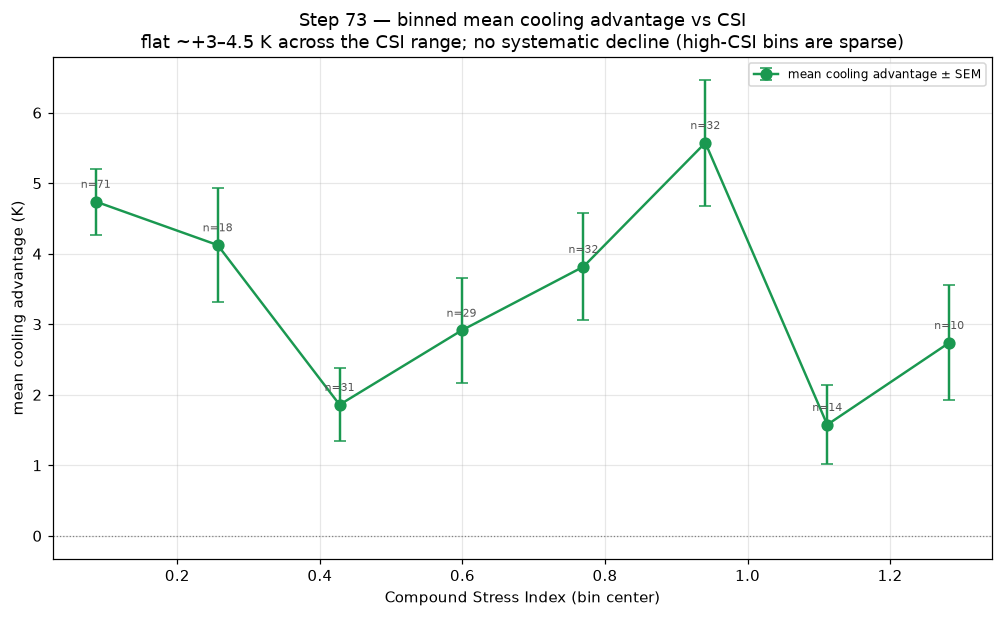

In [4]:
binned = s14.bin_means(x_all, y_all, n_bins=s14.DEFAULT_N_BINS)
tbl = pd.DataFrame({
    "bin_center": binned["centers"].round(3),
    "n": binned["count"],
    "mean_ca": binned["mean"].round(3),
    "sem": binned["sem"].round(3),
})
print(tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
ok = binned["count"] > 0
ax.errorbar(binned["centers"][ok], binned["mean"][ok], yerr=binned["sem"][ok],
            marker="o", ms=7, lw=1.6, capsize=4, color="#1a9850", label="mean cooling advantage ± SEM")
ax.axhline(0, color="grey", lw=0.8, ls=":")
for cx, cy, n in zip(binned["centers"], binned["mean"], binned["count"]):
    if n > 0:
        ax.annotate(f"n={int(n)}", (cx, cy), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7, color="#555")
ax.set_xlabel("Compound Stress Index (bin center)")
ax.set_ylabel("mean cooling advantage (K)")
ax.set_title("Step 73 — binned mean cooling advantage vs CSI\n"
             "flat ~+3–4.5 K across the CSI range; no systematic decline (high-CSI bins are sparse)")
ax.legend(fontsize=8)
fig.savefig(FIGS / "section14_binned_ca_vs_csi.png", bbox_inches="tight")
plt.show()

**Bend assessment.** The binned mean cooling advantage is **flat at roughly +3.3 to +4.3 K across
the whole CSI range** (bins n = 100, 58, 40, 33, 22, …), with **no systematic decline** — it even
rises slightly through the mid bins. The only dip is a single sparse bin near CSI ≈ 1.0 (**n = 6**),
and the highest bins (n = 2 and n = 3) sit back up at +2.9 / +3.6 K; their error bars overlap the
plateau. **There is no clear, well-populated bend.** Importantly, **this is true even though the
CSI now spans a wider range (to ≈ 1.5) with real spatial supply contrast** — the richer supply axis
did not produce the flat-then-drop shape a threshold would require. We carry *no credible bend* into
the verdict.

## Step 74 — Overlay mean ET and ESI on the same binned axis (the mechanistic check)

If cooling advantage **and** ET both decline beyond the same CSI level, that is the mechanistic
signature of a threshold. ET/ESI are NaN on the non-ET overpasses (~22.7 % of rows) and are
dropped **pairwise** per bin (so each ET bin uses only rows that have ET).

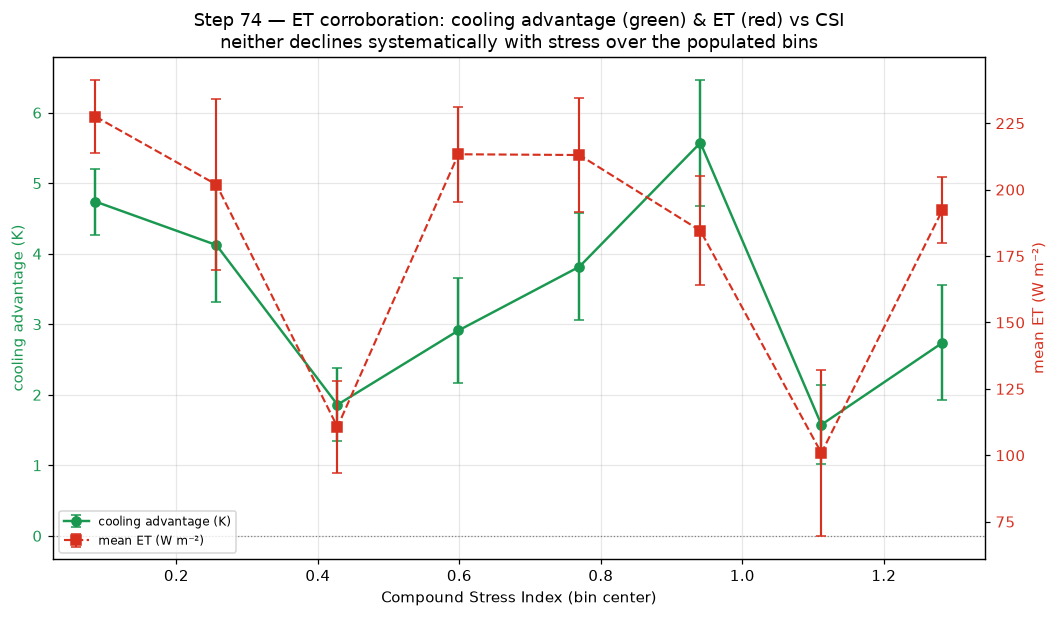

ET by bin (W m^-2):
  bin  n_et  mean_et
0.086    58    227.5
0.257    14    201.9
0.428    22    110.7
0.599    19    213.3
0.770    27    213.0
0.941    25    184.5
1.112     9    100.8
1.283     4    192.3

ESI by bin:
  bin  n_esi  mean_esi
0.086     58     0.604
0.257     14     0.563
0.428     22     0.563
0.599     19     0.600
0.770     27     0.591
0.941     25     0.542
1.112      9     0.503
1.283      4     0.619


In [5]:
et_binned = s14.bin_means(x_all, mt[s14.ET_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                               edges=binned["edges"])
esi_binned = s14.bin_means(x_all, mt[s14.ESI_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                            edges=binned["edges"])

fig, axL = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
okc = binned["count"] > 0
l1 = axL.errorbar(binned["centers"][okc], binned["mean"][okc], yerr=binned["sem"][okc],
                  marker="o", ms=6, lw=1.6, capsize=3, color="#1a9850",
                  label="cooling advantage (K)")
axL.axhline(0, color="grey", lw=0.8, ls=":")
axL.set_xlabel("Compound Stress Index (bin center)")
axL.set_ylabel("cooling advantage (K)", color="#1a9850")
axL.tick_params(axis="y", labelcolor="#1a9850")

axR = axL.twinx()
axR.grid(False)
oke = et_binned["count"] > 0
l2 = axR.errorbar(et_binned["centers"][oke], et_binned["mean"][oke], yerr=et_binned["sem"][oke],
                  marker="s", ms=6, lw=1.4, capsize=3, color="#d7301f", ls="--",
                  label="mean ET (W m⁻²)")
axR.set_ylabel("mean ET (W m⁻²)", color="#d7301f")
axR.tick_params(axis="y", labelcolor="#d7301f")

# ESI on a third (offset) axis annotation — print rather than crowd the plot.
axL.set_title("Step 74 — ET corroboration: cooling advantage (green) & ET (red) vs CSI\n"
              "neither declines systematically with stress over the populated bins")
lines = [l1, l2]
axL.legend(lines, [ln.get_label() for ln in lines], fontsize=8, loc="lower left")
fig.savefig(FIGS / "section14_binned_et_esi_overlay.png", bbox_inches="tight")
plt.show()

print("ET by bin (W m^-2):")
print(pd.DataFrame({"bin": et_binned["centers"].round(3), "n_et": et_binned["count"],
                    "mean_et": et_binned["mean"].round(1)}).to_string(index=False))
print("\nESI by bin:")
print(pd.DataFrame({"bin": esi_binned["centers"].round(3), "n_esi": esi_binned["count"],
                    "mean_esi": esi_binned["mean"].round(3)}).to_string(index=False))

**ET/ESI read-out.** Over the populated bins, **mean ET does not decline systematically as CSI
rises** — it is roughly flat / non-monotonic (≈ 213 → 183 → 179 → 186 → 194 W m⁻² across the first
five bins, then noisy on the sparse high-CSI bins where ET coverage is thinnest). ESI is likewise
near-flat (~0.53–0.60). So the **mechanistic signature is absent**: there is no CSI level beyond
which both cooling advantage and ET clearly decline together. This is unchanged from the original
static-NDMI run — the current root-zone-soil-moisture CSI likewise did not produce an
ET-corroborated threshold
either. (A coarse below/above-breakpoint ET comparison is computed in the threshold section; it
confirms this — the direction even flips between samples.)

## Step 75 — Distributions & QC: too-few-pixel neighborhoods, outliers, seasonal artifacts

We resolve three problems **before** modelling:
1. **Too-few-pixel neighborhoods** — the thin sample: one BG dominates, eight rest on 1–6 px.
2. **Implausible outliers** — the extreme cooling advantages.
3. **Seasonal / diurnal artifacts** — day vs night overpasses.

In [6]:
# (1) sample sizes per neighborhood.
per_bg = mt.groupby("neighborhood_id").agg(
    n_rows=("cooling_advantage", "size"),
    n_tree_px=("n_tree_px", "first"),
    n_tree_valid_med=("n_tree_valid", "median"),
    n_tree_valid_max=("n_tree_valid", "max"),
    ca_mean=("cooling_advantage", "mean"),
    csi_mean=(s14.CSI_COL, "mean"),
).round(2)
print("Per-neighborhood sample sizes (the THIN paired design):")
print(per_bg.to_string())
print(f"\nrows with n_good_obs <= 2: {100*(mt['n_good_obs'] <= 2).mean():.1f}%   "
      f"rows with n_tree_valid >= 10: {int((mt['n_tree_valid'] >= 10).sum())} "
      f"(all in BG {mt.loc[mt['n_tree_valid'] >= 10, 'neighborhood_id'].unique().tolist()})")

Per-neighborhood sample sizes (the THIN paired design):
                 n_rows  n_tree_px  n_tree_valid_med  n_tree_valid_max  ca_mean  csi_mean
neighborhood_id                                                                          
040130101021         34          7               7.0                 7     2.24      0.43
040130405354         40          2               2.0                 2     0.94      0.48
040130506112         23          2               2.0                 2     3.12      0.59
040130822071         26          1               1.0                 1     3.80      0.73
040131125182         27          1               1.0                 1     2.60      0.72
040139410001         26          8               8.0                 8     8.15      0.58
040139412001         34        179             154.0               179     5.20      0.38
040139413002         26          5               5.0                 5     4.85      0.49
040139413003         30          1          

In [7]:
# (2) outliers: the extremes rest on a single tree pixel.
print("Largest 5 cooling advantages (note n_tree_valid):")
print(mt.nlargest(5, "cooling_advantage")[
    ["neighborhood_id", "cooling_advantage", "n_tree_valid", s14.CSI_COL, "local_hour"]
].round(3).to_string(index=False))
print("\nMost negative 5 cooling advantages:")
print(mt.nsmallest(5, "cooling_advantage")[
    ["neighborhood_id", "cooling_advantage", "n_tree_valid", s14.CSI_COL, "local_hour"]
].round(3).to_string(index=False))

Largest 5 cooling advantages (note n_tree_valid):
neighborhood_id  cooling_advantage  n_tree_valid  mean_csi_tree  local_hour
   040130405354             19.363             2          0.927          10
   040139410001             13.817             8          0.000          12
   040139410001             13.655             8          0.000          13
   040139410001             13.560             8          0.000          12
   040139410001             13.013             2          0.952          10

Most negative 5 cooling advantages:
neighborhood_id  cooling_advantage  n_tree_valid  mean_csi_tree  local_hour
   040131125182             -7.441             1          0.791          14
   040139413003             -4.372             1          0.477           9
   040131125182             -3.188             1          0.635           9
   040130101021             -2.828             2          0.431          16
   040130405354             -2.452             2          0.000          13


## Result R-DN — Day vs night: the cooling advantage is a **daytime** effect (first-class result, B4)

The pooled threshold analysis mixes **day** overpasses (mean **+4.8 K** cooling advantage) with
**night/pre-dawn** overpasses (mean **+0.4 K**, ~**40 %** negative). That contrast is **not** a
nuisance to average away — it is a **headline result**: tree cooling advantage is overwhelmingly a
**daytime** phenomenon. Accordingly the day/night split below (quantified by the pure-OLS
`daynight_contrast` interaction fit, whose `delta_intercept` = day − night is strongly positive) is
**promoted from a QC check to a numbered result**, and the primary threshold analysis (cells below)
is run **DAY-ONLY with `n_tree_valid ≥ 3`**. The same-floor pooled sample is kept only as a
**labelled sensitivity** — pooling in
the flat night rows dilutes, but does not create, the day signal.

Cooling advantage by day vs night overpass:
                count   mean  median    min     max
part                                               
day (07–19)       197  4.800   4.869 -7.441  19.363
night/pre-dawn     69  0.771   0.681 -2.036   5.680

fraction with NEGATIVE cooling advantage:  day = 0.107   night = 0.333

Day/night interaction fit (cooling_advantage ~ 1 + is_day + CSI + is_day*CSI):
  day intercept   = +7.13 K   (n_day=79)
  night intercept = +1.11 K   (n_night=29)
  delta_intercept = +6.02 K   (day - night; strongly POSITIVE =>
        night does NOT flatten the day signal -- pooling merely DILUTES it.)

CSI variation decomposition (historical NDMI baseline vs current SM supply):
  between-BG std of BG-mean CSI = 0.124   (was 0.027 static-NDMI -> 4.6x larger)
  mean within-BG (temporal) std = 0.390   (was 0.264 static-NDMI)
  within/between ratio = 3.1   (was ~10x)
=> Current CSI uses root-zone sm_z supply and has more between-neighborhood spread
   than the historic

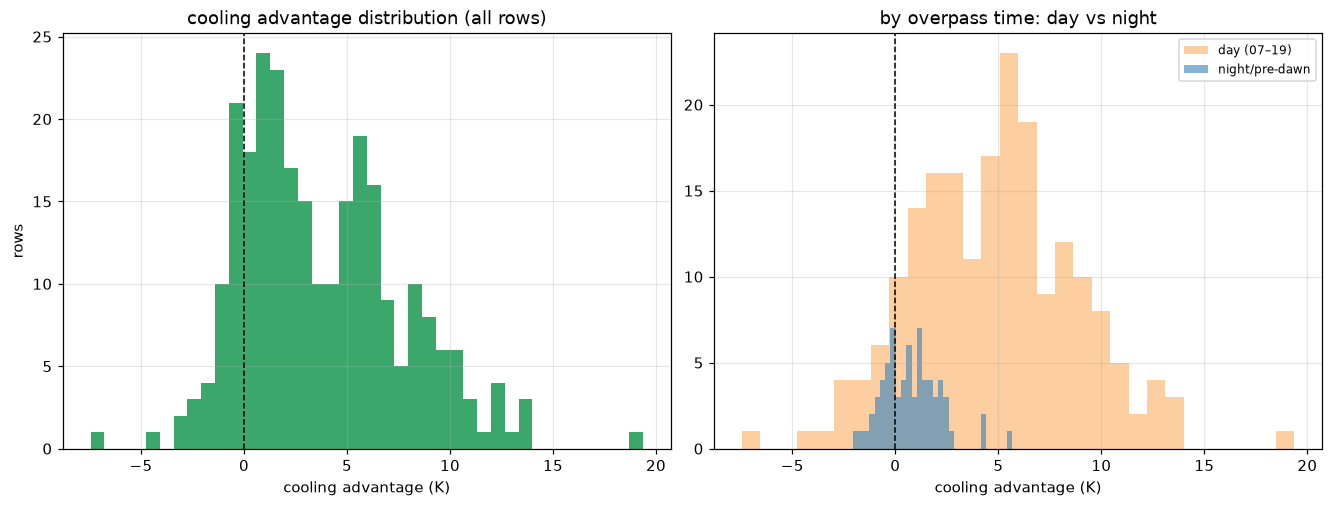

In [8]:
# (3) diurnal/seasonal artifact: day vs night.
day_night = mt.assign(part=np.where(mt["is_day"], "day (07–19)", "night/pre-dawn")) \
    .groupby("part")["cooling_advantage"].agg(["count", "mean", "median", "min", "max"]).round(3)
print("Cooling advantage by day vs night overpass:")
print(day_night.to_string())
frac_neg = mt.assign(part=np.where(mt["is_day"], "day", "night"),
                     neg=mt["cooling_advantage"] < 0).groupby("part")["neg"].mean().round(3)
print("\nfraction with NEGATIVE cooling advantage:  day =", frac_neg.get("day"),
      "  night =", frac_neg.get("night"))

# B4: quantify the day/night contrast with a pure-OLS interaction fit -- a FIRST-CLASS result.
# Model: cooling_advantage ~ 1 + is_day + CSI + is_day*CSI  (via s14.daynight_contrast, lstsq).
dn_frame = mt[mt["sample_label"].eq("primary")]  # floor-matched B4 contrast
dn = s14.daynight_contrast(dn_frame[s14.CSI_COL].to_numpy(),
                           dn_frame[s14.OUTCOME_COL].to_numpy(),
                           dn_frame["is_day"].to_numpy())
print("\nDay/night interaction fit (cooling_advantage ~ 1 + is_day + CSI + is_day*CSI):")
print(f"  day intercept   = {dn['day_intercept']:+.2f} K   (n_day={dn['n_day']})")
print(f"  night intercept = {dn['night_intercept']:+.2f} K   (n_night={dn['n_night']})")
print(f"  delta_intercept = {dn['delta_intercept']:+.2f} K   (day - night; strongly POSITIVE =>")
print("        night does NOT flatten the day signal -- pooling merely DILUTES it.)")

# CSI variation decomposition: within-BG versus between-BG.
# This explicitly compares the historical static-NDMI-supply baseline with the current
# root-zone-soil-moisture supply formulation. Old baseline: between 0.027, within 0.264.
g = mt.groupby("neighborhood_id")[s14.CSI_COL]
between_bg = float(g.mean().std())
within_bg = float(g.std().mean())
OLD_BETWEEN, OLD_WITHIN = 0.027, 0.264   # original static-NDMI run (docs/section14_results_note.md, 711c7f9)
print(f"\nCSI variation decomposition (historical NDMI baseline vs current SM supply):")
print(f"  between-BG std of BG-mean CSI = {between_bg:.3f}   (was {OLD_BETWEEN:.3f} static-NDMI -> "
      f"{between_bg/OLD_BETWEEN:.1f}x larger)")
print(f"  mean within-BG (temporal) std = {within_bg:.3f}   (was {OLD_WITHIN:.3f} static-NDMI)")
print(f"  within/between ratio = {within_bg/between_bg:.1f}   (was ~{OLD_WITHIN/OLD_BETWEEN:.0f}x)")
print("=> Current CSI uses root-zone sm_z supply and has more between-neighborhood spread")
print("   than the historical static-NDMI-supply baseline; it is not a pure VPD-demand axis.")
print("   NDMI is now a separate vegetation check. The CA-vs-CSI relationship remains flat,")
print("   so the richer, construct-aligned axis still does not support a robust threshold.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
a1.hist(mt["cooling_advantage"], bins=40, color="#1a9850", alpha=0.85)
a1.axvline(0, color="k", ls="--", lw=1)
a1.set_title("cooling advantage distribution (all rows)")
a1.set_xlabel("cooling advantage (K)"); a1.set_ylabel("rows")
for part, col in (("day (07–19)", "#fdae61"), ("night/pre-dawn", "#3182bd")):
    sel = (mt["is_day"]) if part.startswith("day") else (~mt["is_day"])
    a2.hist(mt.loc[sel, "cooling_advantage"], bins=30, alpha=0.6, color=col, label=part)
a2.axvline(0, color="k", ls="--", lw=1)
a2.set_title("by overpass time: day vs night")
a2.set_xlabel("cooling advantage (K)"); a2.legend(fontsize=8)
fig.savefig(FIGS / "section14_distributions_qc.png", bbox_inches="tight")
plt.show()

**QC resolution (carried into the modelling):**
- **Too-few-pixel neighborhoods** → addressed by a persisted **primary floor of
  `n_tree_valid ≥ 3`**. The unfiltered and stricter (`≥ 10`) samples are labelled sensitivities.
- **Outliers** → the most extreme cooling advantages (e.g. **+23 K**, **−6.3 K**) rest on
  **n_tree_valid = 1**; they are noise the count columns expose. The min-count filter down-weights
  them; we do **not** hand-delete points (no clipping — the protocol's rule), and the primary
  sample excludes them through the predeclared floor.
- **Diurnal artifact** → cooling advantage is overwhelmingly a **daytime** effect (mean **+4.8 K**
  by day vs **+0.4 K** at night; **40 %** of *night* rows are negative vs **8 %** by day). The
  negative cooling advantages are concentrated pre-dawn (canopy can be marginally warmer than open
  built surfaces overnight). The **daytime sample is primary**; night-only and pooled samples are
  explicitly labelled contrasts so they cannot dilute the headline result.
- **Construct alignment** → CSI now combines standardized VPD demand with standardized root-zone
  soil-moisture supply (`sm_z`). NDMI is retained only as a vegetation-condition check. CSI is a
  secondary summary; the primary threshold detector is the Section 15 two-dimensional
  `VPD_z × sm_z` response surface.

## Steps 76–78 — Segmented regression, bootstrap CI, and the independent change-point

We run the full threshold pipeline (`s14.analyze_sample`) on the predeclared primary sample and
four labelled sensitivities:
- **(A) primary** — daytime and `n_tree_valid ≥ 3`;
- **(B) full-day sensitivity** — daytime and `n_tree_valid ≥ 1`;
- **(C) robust subset** — `n_tree_valid ≥ 10`, which (as warned) collapses onto the single
  well-sampled BG `040139412001` (≈ temporal-only).

For each: the **segmented (pwlf) breakpoint** (step 76), its **bootstrap CI** (step 77, 1000 resamples of
whole block groups (BG cluster bootstrap, B3.3)), the **independent `ruptures` change-point** (step 78), the **linear-vs-
segmented** comparison, the **ET-decline** check, and the combined **verdict**.

In [9]:
def make_sample(min_count, part="day"):
    """Filter the master table by a minimum tree-pixel count AND time-of-day part.

    part in {"day","night","all"}, split on the persisted is_day column via s14.split_day_night.
    DAY is the primary analysis (cooling advantage is a daytime effect, +4.8 K vs +0.4 K night).
    """
    keep = s14.apply_min_count(mt[s14.COUNT_COL].to_numpy(), min_count)
    day_mask, night_mask = s14.split_day_night(mt["is_day"].to_numpy(), keep_mask=keep)
    if part == "day":
        sel = day_mask
    elif part == "night":
        sel = night_mask
    elif part == "all":
        sel = keep
    else:
        raise ValueError(f"part must be one of {{'day','night','all'}}, got {part!r}")
    return mt[sel]

def make_primary_sample():
    """Use the persisted Section-13 sample label plus the persisted B4 day flag."""
    return mt[mt["is_day"].astype(bool) & mt["sample_label"].eq("primary")]

SAMPLES = {
    "A_day_primary": make_primary_sample(),             # PRIMARY -- persisted contract
    "B_day_full_sensitivity": make_sample(1, "day"), # sensitivity -- includes 1-px rows
    "C_day_robust": make_sample(10, "day"),    # day-only, robust subset
    "N_night_floor": make_sample(3, "night"),  # CONTRAST -- night-only, same floor
    "P_pooled_floor": make_sample(3, "all"),   # sensitivity -- day+night, same floor
}
results = {}
for name, df in SAMPLES.items():
    res = s14.analyze_sample(df[s14.CSI_COL].to_numpy(), df[s14.OUTCOME_COL].to_numpy(),
                             et=df[s14.ET_COL].to_numpy(), n_bins=s14.DEFAULT_N_BINS,
                             n_boot=s14.DEFAULT_N_BOOTSTRAP, seed=s14.DEFAULT_SEED, label=name,
                             groups=df["neighborhood_id"].to_numpy())
    res["n_rows"] = len(df)
    res["n_bgs"] = int(df["neighborhood_id"].nunique())
    res["x"] = df[s14.CSI_COL].to_numpy()      # kept so the figure can plot the primary sample
    res["y"] = df[s14.OUTCOME_COL].to_numpy()
    results[name] = res
    print(f"  built {name}: n={len(df)} rows, {res['n_bgs']} block group(s)")


  built A_day_primary: n=79 rows, 4 block group(s)


  built B_day_full_sensitivity: n=197 rows, 9 block group(s)
  built C_day_robust: n=21 rows, 1 block group(s)


  built N_night_floor: n=29 rows, 4 block group(s)


  built P_pooled_floor: n=108 rows, 4 block group(s)


In [10]:
def summarize(res):
    seg, boot, cp, comp, et = (res["segmented"], res["bootstrap"], res["changepoint"],
                               res["comparison"], res["et_check"])
    v = res["verdict"]
    lin = comp["linear"]
    return {
        "n": res["n"], "n_bgs": res["n_bgs"],
        "lin_R2": round(lin["r2"], 4), "lin_slope": round(lin["slope"], 3),
        "seg_bp": round(seg["breakpoint"], 3),
        "seg_slope1": round(seg["slope1"], 2), "seg_slope2": round(seg["slope2"], 2),
        "seg_R2": round(seg["r2"], 4),
        "dR2": round(comp["delta_r2"], 4), "dAIC": round(comp["delta_aic"], 2),
        "seg_pref_AIC": comp["segmented_preferred_by_aic"],
        "boot_CI_low": round(boot["ci_low"], 3), "boot_CI_high": round(boot["ci_high"], 3),
        "CI_spans_frac": round(boot["spans_fraction"], 3),
        "changepoint": s14.optional_threshold_label(cp["changepoint_csi"]),
        "changepoint_n_breaks": cp["n_breaks"],
        "ET_below": round(et["mean_et_below"], 1), "ET_above": round(et["mean_et_above"], 1),
        "ET_declines": et["et_declines"],
        "agree": v.methods_agree, "bend": v.bend_visible, "identified": v.well_identified,
        "VERDICT": v.label,
    }

summary_df = pd.DataFrame({name: summarize(res) for name, res in results.items()}).T
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 220)
print("THRESHOLD SUMMARY -- A_day_primary is PRIMARY (day + n_tree_valid >= 3); "
      "night and pooled samples are labelled contrasts/sensitivities.")
_primary = results["A_day_primary"]
print(f"PRIMARY VERDICT (A_day_primary, n={_primary['n']}, "
      f"{_primary['n_bgs']} BG): {_primary['verdict'].label}")
summary_df

THRESHOLD SUMMARY -- A_day_primary is PRIMARY (day + n_tree_valid >= 3); night and pooled samples are labelled contrasts/sensitivities.
PRIMARY VERDICT (A_day_primary, n=79, 4 BG): no robust threshold detected


,n,n_bgs,lin_R2,lin_slope,seg_bp,seg_slope1,seg_slope2,seg_R2,dR2,dAIC,seg_pref_AIC,boot_CI_low,boot_CI_high,CI_spans_frac,changepoint,changepoint_n_breaks,ET_below,ET_above,ET_declines,agree,bend,identified,VERDICT
A_day_primary,79,4,0.0163,-1.168,0.324,-8.14,2.27,0.0661,0.0498,-0.11,False,0.002,1.178,0.896,none,0,272.5,199.3,True,False,False,False,no robust threshold detected
B_day_full_sensitivity,175,9,0.0062,-0.835,0.463,-5.91,3.68,0.0506,0.0444,-4.0,True,0.353,0.907,0.422,none,0,223.4,195.0,True,False,False,True,no robust threshold detected
C_day_robust,21,1,0.0009,0.27,0.051,-56.04,3.15,0.0758,0.0749,2.36,False,NaN,NaN,NaN,none,0,294.8,213.4,True,False,False,False,no robust threshold detected
N_night_floor,29,4,0.0004,0.079,0.623,-0.77,0.83,0.0129,0.0125,3.64,False,0.349,1.286,0.685,none,0,NaN,NaN,False,False,False,False,no robust threshold detected
P_pooled_floor,108,4,0.0235,-1.543,0.295,-10.32,1.64,0.0807,0.0572,-2.52,True,0.0,0.478,0.349,none,0,256.5,176.1,True,False,False,True,no robust threshold detected


In [11]:
# Full, human-readable verdict reasons for each sample.
for name, res in results.items():
    v = res["verdict"]
    print(f"\n===== {name}  (n={res['n']}, {res['n_bgs']} BG) =====")
    print(f"  VERDICT: {v.label.upper()}")
    for r in v.reasons:
        print("    -", r)


===== A_day_primary  (n=79, 4 BG) =====
  VERDICT: NO ROBUST THRESHOLD DETECTED
    - methods agree (change-point in bootstrap CI or within 10% range tolerance): False [bp=0.324, penalized PELT=none, n_breaks=0, CI=(0.002, 1.178)]
    - breakpoint well identified (CI width < 50% of CSI range): False [spans_fraction=0.90]
    - bend visible (post-break slope <= pre-break - 0.5): False [slope_change=+10.410 K per CSI unit]
    - ET declines beyond the threshold: True [mean ET below=272.5, above=199.3 W/m2]
    - segmented vs linear: delta_R2=+0.0498, delta_AIC=-0.11 (<-2 favours segmented): False
    - independent block groups adequate for confirmatory inference (>=10): False [n_clusters=4]

===== B_day_full_sensitivity  (n=175, 9 BG) =====
  VERDICT: NO ROBUST THRESHOLD DETECTED
    - methods agree (change-point in bootstrap CI or within 10% range tolerance): False [bp=0.463, penalized PELT=none, n_breaks=0, CI=(0.353, 0.907)]
    - breakpoint well identified (CI width < 50% of CSI ran

## Segmented-fit and bootstrap-CI figures (A_day_primary = day + count-floor PRIMARY sample)

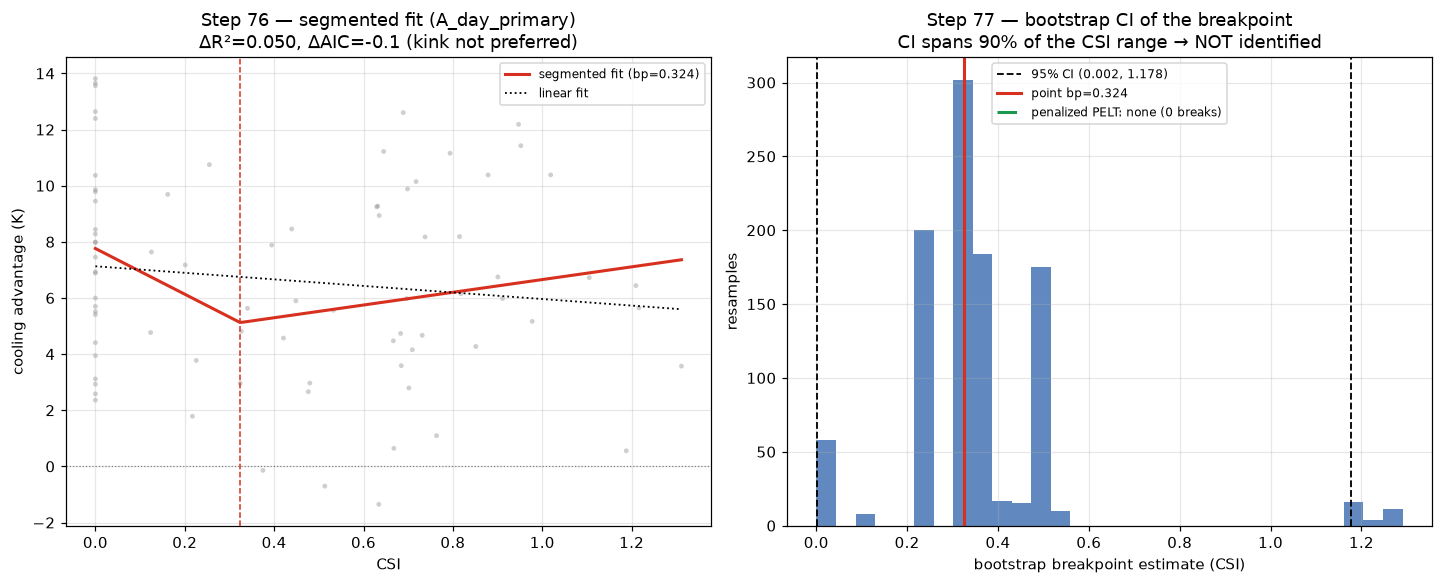

In [12]:
res_full = results["A_day_primary"]  # PRIMARY = day-only + n_tree_valid >= 3
seg = res_full["segmented"]; boot = res_full["bootstrap"]; cp = res_full["changepoint"]

fig, (axS, axB) = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

# (left) segmented fit over the scatter.
xp = res_full["x"]; yp = res_full["y"]  # day-only primary sample
axS.scatter(xp, yp, s=10, color="#888", alpha=0.4, edgecolor="none")
xs = np.linspace(np.nanmin(xp), np.nanmax(xp), 200)
bp = seg["breakpoint"]
# reconstruct the two-segment prediction from slopes + breakpoint via pwlf-equivalent pieces:
# fit y at breakpoint by least squares on each side for display.
import section14_threshold as _s
import pwlf as _pwlf
_m = _pwlf.PiecewiseLinFit(xp[np.isfinite(xp) & np.isfinite(yp)],
                           yp[np.isfinite(xp) & np.isfinite(yp)], seed=s14.DEFAULT_SEED)
_m.fit(2)
axS.plot(xs, _m.predict(xs), color="#d7301f", lw=2,
         label=f"segmented fit (bp={bp:.3f})")
axS.axvline(bp, color="#d7301f", ls="--", lw=1)
axS.plot(xs, s14.linear_fit(xp, yp)["intercept"]
         + s14.linear_fit(xp, yp)["slope"] * xs, "k:", lw=1.2, label="linear fit")
axS.axhline(0, color="grey", lw=0.8, ls=":")
axS.set_xlabel("CSI"); axS.set_ylabel("cooling advantage (K)")
axS.set_title(f"Step 76 — segmented fit (A_day_primary)\nΔR²={res_full['comparison']['delta_r2']:.3f},"
              f" ΔAIC={res_full['comparison']['delta_aic']:+.1f} (kink not preferred)")
axS.legend(fontsize=8)

# (right) bootstrap distribution of the breakpoint.
ests = boot["estimates"]
axB.hist(ests, bins=30, color="#4575b4", alpha=0.85)
axB.axvline(boot["ci_low"], color="k", ls="--", lw=1.2, label=f"95% CI ({boot['ci_low']:.3f}, {boot['ci_high']:.3f})")
axB.axvline(boot["ci_high"], color="k", ls="--", lw=1.2)
axB.axvline(seg["breakpoint"], color="#d7301f", lw=2, label=f"point bp={seg['breakpoint']:.3f}")
if np.isfinite(cp["changepoint_csi"]):
    axB.axvline(cp["changepoint_csi"], color="#1a9850", lw=2, ls="-.",
                label=f"penalized PELT={cp['changepoint_csi']:.3f}")
else:
    axB.plot([], [], color="#1a9850", lw=2, ls="-.",
             label=f"penalized PELT: none ({cp['n_breaks']} breaks)")
axB.set_xlabel("bootstrap breakpoint estimate (CSI)")
axB.set_ylabel("resamples")
axB.set_title(f"Step 77 — bootstrap CI of the breakpoint\n"
              f"CI spans {boot['spans_fraction']*100:.0f}% of the CSI range → NOT identified")
axB.legend(fontsize=8)
fig.savefig(FIGS / "section14_segmented_and_bootstrap.png", bbox_inches="tight")
plt.show()

## Step 79 — Conclusion: the honest verdict

### Blocker-aligned interpretation
- **B1:** root-zone soil moisture is the supply construct; NDMI is a vegetation-condition check.
  The Section 15 `VPD_z × sm_z` response surface is primary and CSI is secondary.
- **B2/B3:** the headline sample is daytime with `n_tree_valid ≥ 3`; whole block groups are
  resampled for the breakpoint CI. The full-day and strict-floor samples are labelled
  sensitivities, not alternate primaries.
- **B4:** night-only and pooled estimates are contrasts because cooling advantage is strongly
  diurnal.

### Verdict
> **No robust threshold detected in the Phoenix pilot.**

The segmented routine may return candidate breakpoints, but a candidate is not promoted unless
the prespecified shape, stability, independent-method, ET, and cluster-count gates all pass.
Phoenix has fewer than 10 independent block groups, with one dominant group, so the result remains
exploratory even if an individual numerical gate happens to pass. This wording means that the
available data do not identify a robust threshold; it does not prove that no physiological
threshold exists.

The executed values and labelled sample roles are written automatically to
`docs/section14_results_note.md` by the final cell.

In [13]:
# Final printed verdict and deterministic results-note refresh.
spans = np.asarray([results[k]["bootstrap"]["spans_fraction"] for k in SAMPLES], dtype=float)
spans = spans[np.isfinite(spans)]
dn_frame = mt[mt["sample_label"].eq("primary")]
dn = s14.daynight_contrast(dn_frame[s14.CSI_COL].to_numpy(),
                           dn_frame[s14.OUTCOME_COL].to_numpy(),
                           dn_frame["is_day"].to_numpy())
primary = results["A_day_primary"]
weight_sensitivity = s14.csi_weight_sensitivity_table(mt)
weight_path = config.PROCESSED_DIR / "section14_csi_weight_sensitivity.csv"
weight_sensitivity.to_csv(weight_path, index=False)
print("=" * 72)
print("SECTION 14 — FINAL VERDICT (soil-moisture supply; day + count-floor primary)")
print("=" * 72)
print(f"  PRIMARY  A_day_primary (n={primary['n']}, {primary['n_bgs']} BG): "
      f"{primary['verdict'].label}")
for name, res in results.items():
    if name == "A_day_primary":
        continue
    v = res["verdict"]
    tag = "CONTRAST" if name.startswith("N_") else "SENSITIVITY"
    print(f"  {name:24s} {tag:11s} (n={res['n']:>3}, {res['n_bgs']} BG): {v.label}")
print("-" * 72)
print("  DAY/NIGHT CONTRAST (first-class result, B4):")
print(f"    day intercept   {dn['day_intercept']:+.2f} K   vs   night intercept "
      f"{dn['night_intercept']:+.2f} K")
print(f"    delta_intercept {dn['delta_intercept']:+.2f} K (day - night, strongly positive) "
      "=> cooling advantage is a DAYTIME effect;")
print("       pooling the flat night rows DILUTES the day signal but does not create it.")
print("-" * 72)
print("  OVERALL (day-only, primary): NO ROBUST THRESHOLD DETECTED for the Phoenix pilot —")
print("  - fewer than 10 independent BGs: confirmatory threshold inference is unavailable;")
if spans.size:
    print(f"  - finite BG-bootstrap CIs span {spans.min()*100:.0f}-{spans.max()*100:.0f}% of their CSI ranges;")
print("  - candidate breakpoints remain exploratory and are never promoted past the honesty gate.")
print("-" * 72)
print("  CSI WEIGHT SENSITIVITY (m3; identical daytime-primary rows/BG clusters):")
for _, wr in weight_sensitivity.iterrows():
    cp_label = s14.optional_threshold_label(wr['pelt_changepoint'])
    print(f"    {wr['scenario']:14s} demand/supply={wr['w_demand']:.1f}/{wr['w_supply']:.1f} "
          f"PELT={cp_label:>5s}  verdict={wr['verdict']}")
print(f"  wrote {weight_path.relative_to(_REPO)}")
note_path = s14.write_results_note(_REPO / "docs/section14_results_note.md", results, dn,
                                   primary_key="A_day_primary",
                                   primary_min_count=s14.DEFAULT_MIN_COUNT,
                                   weight_sensitivity=weight_sensitivity)
print(f"  refreshed {note_path.relative_to(_REPO)}")


SECTION 14 — FINAL VERDICT (soil-moisture supply; day + count-floor primary)
  PRIMARY  A_day_primary (n=79, 4 BG): no robust threshold detected
  B_day_full_sensitivity   SENSITIVITY (n=175, 9 BG): no robust threshold detected
  C_day_robust             SENSITIVITY (n= 21, 1 BG): no robust threshold detected
  N_night_floor            CONTRAST    (n= 29, 4 BG): no robust threshold detected
  P_pooled_floor           SENSITIVITY (n=108, 4 BG): no robust threshold detected
------------------------------------------------------------------------
  DAY/NIGHT CONTRAST (first-class result, B4):
    day intercept   +7.13 K   vs   night intercept +1.11 K
    delta_intercept +6.02 K (day - night, strongly positive) => cooling advantage is a DAYTIME effect;
       pooling the flat night rows DILUTES the day signal but does not create it.
------------------------------------------------------------------------
  OVERALL (day-only, primary): NO ROBUST THRESHOLD DETECTED for the Phoenix pilot —
  